## Climate Data, a brief introduction

Section by Margaret Duffy\
In this class we'll see and use examples of the three main kinds of climate data: observations, reanalysis, and models. We'll especially use reanalysis and models.

## 1. Types of climate data

# Observations:

Direct measurements of the real climate system, collected through instruments such as weather stations, satellites, ocean buoys, and ice cores.\
Examples: NASA satellite temperature observations and NOAA surface temperature records\
Pros: Usually the closest thing we have to the "Truth"\
Cons: Can have biases (more than one might expect!), typically not gridded, there's only one "realization" of Earth's climate

# Reanalyses:

Gridded reconstructions of past weather and climate that combine observations with a weather model to produce a complete, gridded picture of the climate system.\
Examples: ERA5 (ECMWF) and NCEP (NOAA)\
Pros: Typically the closest complete, gridded product to the "Truth"\
Cons: Includes biases from both the ingested observations and the weather model, trends are unreliable, still only one "realization"

Let's peek at surface temperature in NCEP reanalysis

In [1]:
# import stuff
import climlab
import xarray as xr

In [2]:
ncep_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.reanalysis.derived/"
ncep_Ts = xr.open_dataset( ncep_url + "surface_gauss/skt.sfc.mon.1981-2010.ltm.nc", decode_times=False)

In [3]:
print(ncep_Ts)

<xarray.Dataset> Size: 2MB
Dimensions:             (time: 12, nbnds: 2, lat: 94, lon: 192)
Coordinates:
  * time                (time) float64 96B -6.571e+05 -6.57e+05 ... -6.567e+05
  * lat                 (lat) float32 376B 88.54 86.65 84.75 ... -86.65 -88.54
  * lon                 (lon) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
Dimensions without coordinates: nbnds
Data variables:
    climatology_bounds  (time, nbnds) float64 192B ...
    skt                 (time, lat, lon) float32 866kB ...
    valid_yr_count      (time, lat, lon) float32 866kB ...
Attributes:
    title:                          4x daily NMC reanalysis
    description:                    Data is from NMC initialized reanalysis\n...
    platform:                       Model
    Conventions:                    COARDS
    not_missing_threshold_percent:  minimum 3% values input to have non-missi...
    history:                        Created 2011/07/12 by doMonthLTM\nConvert...
    dataset_title:             

The variable we're interested in is skt, which is skin temperature

In [4]:
print(ncep_Ts['skt'])

<xarray.DataArray 'skt' (time: 12, lat: 94, lon: 192)> Size: 866kB
[216576 values with dtype=float32]
Coordinates:
  * time     (time) float64 96B -6.571e+05 -6.57e+05 ... -6.568e+05 -6.567e+05
  * lat      (lat) float32 376B 88.54 86.65 84.75 82.85 ... -84.75 -86.65 -88.54
  * lon      (lon) float32 768B 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Attributes:
    long_name:     Monthly Long Term Mean of Skin Temperature
    valid_range:   [-2000.  2000.]
    units:         degC
    precision:     1
    var_desc:      Skin Temperature
    level_desc:    Surface
    statistic:     Long Term Mean
    parent_stat:   Mean
    actual_range:  [-79.6602    40.252453]
    dataset:       NCEP Reanalysis Derived Products
    _ChunkSizes:   [  1  94 192]


We can see that this dataset has coordinates time, lat, lon and units degC (degrees Celsius)

Climate models:

Climate models come in a "hierarchy" ranging from simple, pencil-and-paper models to fully-coupled Global Climate Models (GCMs).\
Examples: Read on! We'll see a lot in this class.\
Pros: Can run experiments with different forcings and can run multiple realizations of a climate. The hierarchy of models can be used to build intuition.\
Cons: Biases! Relatedly, global models are computationally expensive, resulting in limited resolution.

# 2. Plotting climate data

Let's plot surface temperature as a function of latitude in different kinds of datasets, starting with the NCEP reanalysis data we already peeked at

In [5]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Latitude')

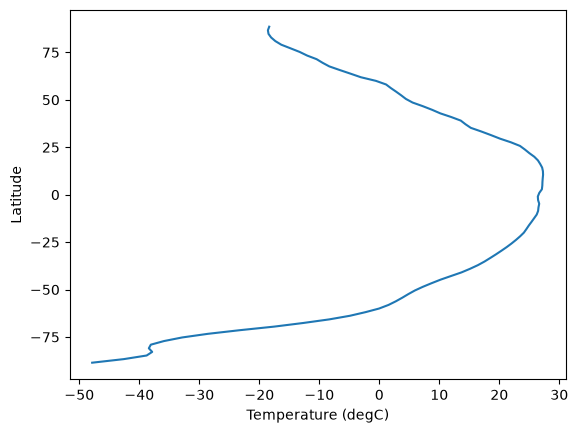

In [12]:
plt.plot(ncep_Ts['skt'].mean('lon').mean('time'), ncep_Ts['lat'])
plt.xlabel('Temperature (' + ncep_Ts['skt'].units + ')')
plt.ylabel('Latitude')

What do you notice about the plot? Does it look right to you? How can you tell?

Later in this unit we'll meet a climate model, CESM. Let's look at how temperature in a climate model (CESM) compares with renalysis

In [14]:
local_path = '../data/ts_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc'
cesm_Ts = xr.open_dataset(local_path)['ts']

/uufs/chpc.utah.edu/sys/installdir/r8/miniforge3_envs/atmos6030/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'ts' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [15]:
cesm_Ts

<xarray.DataArray 'ts' (time: 1980, lat: 192, lon: 288)> Size: 438MB
[109486080 values with dtype=float32]
Coordinates:
  * time     (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        Surface temperature (skin for open ocean)
    description:    Surface temperature (skin for open ocean)
    frequency:      mon
    id:             ts
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Surface Temperature
    type:           real
    units:          K
    variable_id:    ts

Notice that CESM Ts has way more time steps- the NCEP data is a monthly climatology from 1981 to 2010, and the CESM data is monthly data from 1850 to 2014. Let's make the CESM data comparable to the NCEP data.

In [19]:
cesm_Ts_climo = cesm_Ts.sel(time = slice('1981-01-01', '2010-12-31')).groupby("time.month").mean("time")

And we notice that NCEP and CESM have different lat-lon grids, too.

In [20]:
cesm_Ts_climo_interp = cesm_Ts_climo.interp_like(ncep_Ts)

<xarray.DataArray 'ts' (month: 12, lat: 192, lon: 288)> Size: 3MB
array([[[245.66797, 245.66795, 245.66794, ..., 245.66794, 245.66801,
         245.66798],
        [246.40886, 246.371  , 246.23878, ..., 246.45403, 246.4402 ,
         246.42676],
        [246.86252, 246.82324, 246.79828, ..., 247.07812, 247.02716,
         246.96387],
        ...,
        [246.03957, 246.06949, 246.0984 , ..., 245.96176, 245.98708,
         246.01161],
        [245.8482 , 245.86078, 245.87375, ..., 245.80757, 245.82094,
         245.83485],
        [245.55711, 245.55838, 245.5595 , ..., 245.55263, 245.55429,
         245.5558 ]],

       [[235.47421, 235.47414, 235.47423, ..., 235.47415, 235.47412,
         235.47412],
        [236.26944, 236.2238 , 236.07907, ..., 236.33432, 236.31781,
         236.2961 ],
        [236.93304, 236.88022, 236.84366, ..., 237.18605, 237.12505,
         237.04903],
...
        [253.615  , 253.63919, 253.66246, ..., 253.5525 , 253.57237,
         253.59187],
        [253.59013, 253.59715, 253.60442, ..., 253.56694, 253.57494,
         253.58272],
        [253.47775, 253.47853, 253.47919, ..., 253.47508, 253.47607,
         253.47699]],

       [[244.41714, 244.41713, 244.41713, ..., 244.41713, 244.41714,
         244.41716],
        [245.10884, 245.06985, 244.93927, ..., 245.16037, 245.14735,
         245.12871],
        [245.61789, 245.57373, 245.5453 , ..., 245.83626, 245.78497,
         245.7197 ],
        ...,
        [248.53452, 248.56142, 248.58675, ..., 248.4666 , 248.48874,
         248.50987],
        [248.14308, 248.15327, 248.16391, ..., 248.10783, 248.12003,
         248.132  ],
        [247.8184 , 247.81981, 247.82106, ..., 247.81328, 247.81516,
         247.81685]]], shape=(12, 192, 288), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        Surface temperature (skin for open ocean)
    description:    Surface temperature (skin for open ocean)
    frequency:      mon
    id:             ts
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Surface Temperature
    type:           real
    units:          K
    variable_id:    ts